In [1]:
!pip install rank_bm25

Defaulting to user installation because normal site-packages is not writeable


In [2]:
#  Imports 
import json
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

print(" Libraries loaded!")

 Libraries loaded!


In [3]:
#  Load Clean Data 
with open("../data/clean_msmarco.json", "r") as f:
    data = json.load(f)

print(f" Loaded {len(data)} queries!")

 Loaded 4851 queries!


In [4]:
# Build BM25 Index
corpus = []
for item in data:
    for passage in item['passages']:
        corpus.append(passage.lower().split())

bm25 = BM25Okapi(corpus)
print(f" BM25 index built with {len(corpus)} passages!")

 BM25 index built with 39962 passages!


In [5]:
# BM25 Search Function
def bm25_search(query, top_k=10):
    scores = bm25.get_scores(query.lower().split())
    return np.argsort(scores)[::-1][:top_k], np.sort(scores)[::-1][:top_k]

indices, scores = bm25_search("what is machine learning")
print(f"Top result: {' '.join(corpus[indices[0]][:12])}")
print(f"Top scores: {scores[:5].round(4)}")

Top result: learning logs. learning logs are used for students' reflections on the material
Top scores: [15.672  15.6004 15.2978 14.8672 14.67  ]


In [6]:
# Score All Queries
import os

if os.path.exists("../data/bm25_results.json"):
    with open("../data/bm25_results.json", "r") as f:
        results = json.load(f)
    print(f"Loaded {len(results)} results from file!")
else:
    results = []
    for item in tqdm(data):
        indices, scores = bm25_search(item['query'])
        results.append({"query": item['query'], "indices": indices.tolist(), "scores": scores.tolist()})
    with open("../data/bm25_results.json", "w") as f:
        json.dump(results, f)
    print(f"Scored and saved {len(results)} queries!")

100%|██████████████████████████████████████████████████████████████████████████████| 4851/4851 [15:31<00:00,  5.21it/s]


Scored and saved 4851 queries!


In [8]:
# Compute NDCG@10
def ndcg_at_k(labels, scores, k=10):
    order = np.argsort(scores)[::-1][:k]
    dcg = sum(labels[i]/np.log2(r+2) for r, i in enumerate(order) if i < len(labels))
    idcg = sum(1/np.log2(r+2) for r in range(min(sum(labels), k)))
    return dcg/idcg if idcg > 0 else 0

ndcg_scores = [
    ndcg_at_k(np.array(item['labels']), np.array(res['scores']))
    for item, res in zip(data, results)
]

print(f"BM25 NDCG@10: {np.mean(ndcg_scores):.4f}")

BM25 NDCG@10: 0.5068


In [9]:
# Save BM25 NDCG Score
baseline = {"model": "BM25", "ndcg@10": round(np.mean(ndcg_scores), 4)}

with open("../data/baseline_score.json", "w") as f:
    json.dump(baseline, f)

print(f"Baseline saved: {baseline}")

Baseline saved: {'model': 'BM25', 'ndcg@10': np.float64(0.5068)}


In [13]:
# Compute All Baseline Metrics
def safe_metrics(labels, scores):
    labels = np.array(labels)
    scores = np.array(scores[:len(labels)])
    order = np.argsort(scores)[::-1]
    
    mrr = next((1/(r+1) for r, i in enumerate(order) if labels[i]==1), 0)
    p_k = sum(labels[order[:10]])/min(10, len(labels))
    dcg = sum(labels[order[r]]/np.log2(r+2) for r in range(min(10,len(order))))
    idcg = sum(1/np.log2(r+2) for r in range(min(sum(labels),10)))
    ndcg = dcg/idcg if idcg > 0 else 0
    return mrr, p_k, ndcg

metrics = [safe_metrics(item['labels'], res['scores']) for item, res in zip(data, results)]
mrr, p_k, ndcg = np.mean(metrics, axis=0)

baseline = {"model":"BM25", "ndcg@10":round(ndcg,4), "mrr":round(mrr,4), "precision@10":round(p_k,4)}
with open("../data/baseline_score.json","w") as f: json.dump(baseline,f)
print(f"Baseline metrics: {baseline}")

Baseline metrics: {'model': 'BM25', 'ndcg@10': np.float64(0.5069), 'mrr': np.float64(0.3573), 'precision@10': np.float64(0.1406)}


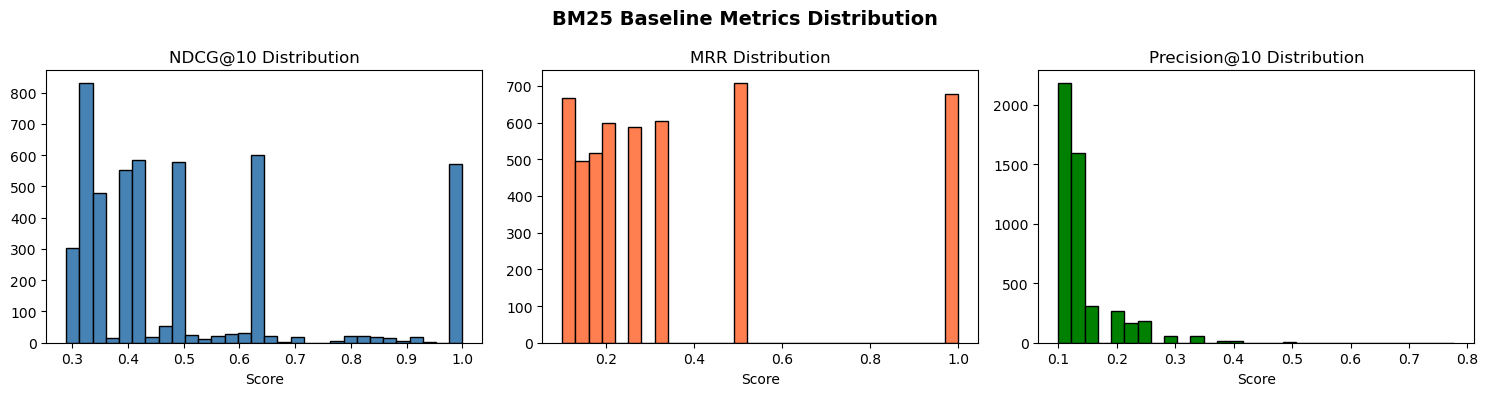

Plot saved!


In [14]:
# Score Distribution Plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(np.array(metrics)[:,2], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title("NDCG@10 Distribution")
axes[0].set_xlabel("Score")

axes[1].hist(np.array(metrics)[:,0], bins=30, color='coral', edgecolor='black')
axes[1].set_title("MRR Distribution")
axes[1].set_xlabel("Score")

axes[2].hist(np.array(metrics)[:,1], bins=30, color='green', edgecolor='black')
axes[2].set_title("Precision@10 Distribution")
axes[2].set_xlabel("Score")

plt.suptitle("BM25 Baseline Metrics Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/bm25_distribution.png", dpi=150)
plt.show()
print("Plot saved!")